
# HPA Usage Mining


### Objetivos

* Mapear e compreender como o **Horizontal Pod Autoscaler (HPA)** é utilizado em repositórios públicos do GitHub.
* Identificar configurações comuns e avançadas, considerando que arquivos YAML podem ser extensos e difíceis de interpretar.
* Investigar o uso de **Helm Charts**, onde muitas vezes aparecem apenas como esqueletos, exigindo análise complementar.
* Avaliar o uso prático do HPA em termos de **versões, métricas e regras** de escalonamento.
* Reproduzir cenários a partir de amostras selecionadas (ex.: 10 projetos sem Helm e 10 com Helm) para entender padrões de configuração.
* Detectar a presença de **scripts de IaC** (Helm, Terraform, Shell) que influenciem a configuração do HPA e reconstruir a cadeia de parâmetros.
* Propor formas de caracterizar o uso do HPA mesmo em casos onde a definição está diluída em ferramentas de automação (Helm/IaC).

## Environment and configuration

In [ ]:

# Create or update .env with user's requested token.
from pathlib import Path

env_text = 'GITHUB_TOKEN=""\n'
Path(".env").write_text(env_text, encoding="utf-8")

# Load environment
import os
from dotenv import load_dotenv

load_dotenv(".env")

GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")
if not GITHUB_TOKEN:
    raise RuntimeError("Missing GITHUB_TOKEN in .env")
print("Environment loaded, token length:", len(GITHUB_TOKEN))


Environment loaded, token length: 40


## Imports, logging, enums, and utility constants

In [6]:

import os, sys, time, json, math, re, queue, hashlib, functools, random, itertools, textwrap, logging
from enum import Enum
from dataclasses import dataclass
from typing import Optional, Dict, Any, List, Tuple, Iterable

import pandas as pd
import numpy as np

import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

import yaml
from yaml.loader import SafeLoader

from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from datetime import datetime, timezone
from collections import defaultdict, Counter

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Logging setup
class LogEvent(Enum):
    START = "START"
    CACHE_HIT = "CACHE_HIT"
    CACHE_MISS = "CACHE_MISS"
    RATE_LIMIT_SLEEP = "RATE_LIMIT_SLEEP"
    REQUEST = "REQUEST"
    REQUEST_RETRY = "REQUEST_RETRY"
    REQUEST_FAIL = "REQUEST_FAIL"
    PARSE_YAML_FAIL = "PARSE_YAML_FAIL"
    HELM_TEMPLATE_DETECTED = "HELM_TEMPLATE_DETECTED"
    PERSIST = "PERSIST"
    DONE = "DONE"
    DIAG = "DIAG"

def build_logger(name: str = "hpaa_usage"):
    logger = logging.getLogger(name)
    logger.setLevel(logging.INFO)
    if not logger.handlers:
        ch = logging.StreamHandler(sys.stdout)
        ch.setLevel(logging.INFO)
        fmt = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")
        ch.setFormatter(fmt)
        logger.addHandler(ch)
    return logger

log = build_logger("hpaa_usage")

# Centralized enums and constants
class Col(Enum):
    OWNER = "Owner"
    PROJECT = "Project"
    FILE_PATH = "File Path"
    HPA_COUNT = "hpa_count"
    APIVERSION = "apiVersion"
    IS_HELM = "Is Helm Template"
    METRIC_NAME = "Metric Name"
    METRIC_TYPE = "Metric Type"
    TARGET_VALUE = "Target Value"
    HAS_BEHAVIOR = "Has Behavior"
    STARS = "stargazers_count"
    CREATED_AT = "created_at"
    PUSHED_AT = "pushed_at"
    FILE_COMMITTED_AT = "file_committed_at"
    MESSAGE = "message"

class Msg(Enum):
    START = "Starting HPA mining pipeline"
    CACHED_HIT = "Cache hit"
    CACHED_MISS = "Cache miss"
    RATE_LIMIT_SLEEP = "Rate limit near"

DATA_DIR = Path("data")
PARTIAL_DIR = DATA_DIR / "partial_results"
PARTIAL_DIR.mkdir(parents=True, exist_ok=True)

def persist_df(df: pd.DataFrame, tag: str) -> Path:
    ts = datetime.now().strftime("%Y-%m-%dT%H:%M:%S")
    out = PARTIAL_DIR / f"{ts}-{tag}.csv"
    df.to_csv(out, index=False)
    log.info("%s - %s", LogEvent.PERSIST.value, out.as_posix())
    return out

def persist_df_both(df: pd.DataFrame, tag: str):
    """Grava CSV com timestamp e também um alias fixo .../phaseX_latest.csv."""
    out_ts = persist_df(df, tag)
    latest = DATA_DIR / f"{tag}_latest.csv"
    df.to_csv(latest, index=False)
    log.info("PERSIST latest alias: %s", latest.resolve().as_posix())
    return out_ts, latest

def list_phase_csvs(tag: str):
    files = sorted(PARTIAL_DIR.glob(f"*-{tag}.csv"))
    print(f"{len(files)} arquivo(s) {tag} com timestamp em {PARTIAL_DIR.resolve().as_posix()}:")
    for p in files[-10:]:
        print(" -", p.name)
    latest_alias = (DATA_DIR / f"{tag}_latest.csv")
    if latest_alias.exists():
        print("Alias latest:", latest_alias.resolve().as_posix(), "size:", latest_alias.stat().st_size, "bytes")
    else:
        print("Alias latest ainda não existe para", tag)

def _pastel(n: int):
    import colorsys
    base = []
    for i in range(max(1, n)):
        hue = i / max(1, n)
        light = 0.78
        sat = 0.35
        r, g, b = colorsys.hls_to_rgb(hue, light, sat)
        base.append("#{0:02x}{1:02x}{2:02x}".format(int(r*255), int(g*255), int(b*255)))
    return base[:n]

def pastel_hist(ax, data, bins=30, title="", xlabel="", ylabel="frequency"):
    ax.hist(data, bins=bins, color=_pastel(1)[0])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, axis="y", alpha=0.2)

def to_dt(s):
    return pd.to_datetime(s, errors="coerce", utc=True)

## GitHub API client with retry, session reuse, and rate-limit awareness

In [7]:

class GitHubClient:
    def __init__(self, token: str, user_agent: str = "hpa-usage-miner"):
        self.base = "https://api.github.com"
        self.session = requests.Session()
        retries = Retry(total=5, backoff_factor=1.2, status_forcelist=[429, 500, 502, 503, 504])
        adapter = HTTPAdapter(max_retries=retries, pool_connections=64, pool_maxsize=64)
        self.session.mount("https://", adapter)
        self.session.headers.update({
            "Authorization": f"token {token}",
            "Accept": "application/vnd.github+json",
            "X-GitHub-Api-Version": "2022-11-28",
            "User-Agent": user_agent
        })

    def _rate_limit_guard(self, resp: requests.Response):
        rl_remaining = int(resp.headers.get("X-RateLimit-Remaining", "1"))
        rl_reset = int(resp.headers.get("X-RateLimit-Reset", "0"))
        if rl_remaining <= 1:
            sleep_for = max(0, rl_reset - int(time.time()) + 2)
            log.info("%s - sleeping %ss until rate limit reset", LogEvent.RATE_LIMIT_SLEEP.value, sleep_for)
            time.sleep(sleep_for)

    def get(self, path: str, params: Optional[dict] = None) -> dict:
        url = f"{self.base}{path}"
        try:
            resp = self.session.get(url, params=params, timeout=30)
            if resp.status_code == 403 and "rate limit" in resp.text.lower():
                self._rate_limit_guard(resp)
                resp = self.session.get(url, params=params, timeout=30)
            self._rate_limit_guard(resp)
            resp.raise_for_status()
            return resp.json()
        except requests.RequestException as e:
            log.warning("%s - %s %s", LogEvent.REQUEST_FAIL.value, url, e)
            raise

gh = GitHubClient(GITHUB_TOKEN)
print("GitHub client ready.")


GitHub client ready.


## Disk cache helpers

In [8]:

CACHE_DIR = Path("data/.cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _hash_key(s: str) -> str:
    return hashlib.sha1(s.encode("utf-8")).hexdigest()

def cache_get(key: str) -> Optional[dict]:
    p = CACHE_DIR / f"{_hash_key(key)}.json"
    if p.exists():
        log.info("%s - %s", Msg.CACHED_HIT.value, key)
        with p.open("r", encoding="utf-8") as f:
            return json.load(f)
    log.info("%s - %s", Msg.CACHED_MISS.value, key)
    return None

def cache_set(key: str, value: dict) -> None:
    p = CACHE_DIR / f"{_hash_key(key)}.json"
    with p.open("w", encoding="utf-8") as f:
        json.dump(value, f)


## Phase 1, search repositories that likely contain HPA manifests

In [9]:
# Fase 1 sharded, robusta e com validação
import time
import pandas as pd
from pathlib import Path

PARTIAL_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED_COLS_P1 = ["repo_full_name", "path", "html_url"]

# Parâmetros máximos suportados pelo GitHub Code Search
PHASE1_PER_PAGE = 100           # máximo permitido pelo endpoint
PHASE1_PAGES_PER_SHARD = 10     # 10 páginas x 100 itens = ~1000 por shard
PHASE1_MIN_SLEEP = 1.0          # breve pausa entre páginas para reduzir throttle

# Shards de busca para ampliar recall e contornar limite de 1000 por consulta
PHASE1_SHARDS = [
    # HPA explícito
    'language:yaml "HorizontalPodAutoscaler"',
    'language:yml  "HorizontalPodAutoscaler"',
    'language:yaml "kind: HorizontalPodAutoscaler"',
    'language:yaml "apiVersion: autoscaling/v2" "HorizontalPodAutoscaler"',
    'language:yaml "apiVersion: autoscaling/v1" "HorizontalPodAutoscaler"',

    # Estruturas típicas de HPA v2
    'language:yaml "metrics:" "HorizontalPodAutoscaler"',
    'language:yaml "scaleTargetRef" "HorizontalPodAutoscaler"',
    'language:yaml "averageUtilization" "HorizontalPodAutoscaler"',
    'language:yaml "external:" "HorizontalPodAutoscaler"',
    'language:yaml "containerResource" "HorizontalPodAutoscaler"',

    # Heurística para Helm
    'language:yaml path:templates "HorizontalPodAutoscaler"',
    'language:yaml path:charts    "HorizontalPodAutoscaler"',

    # Variantes com hpa solto
    'language:yaml hpa "HorizontalPodAutoscaler"',
    'language:yml  hpa "HorizontalPodAutoscaler"',

    # Nomes comuns de arquivo
    'language:yaml filename:autoscaling.yaml "HorizontalPodAutoscaler"',
    'language:yaml filename:horizontalpodautoscaler.yaml "kind: HorizontalPodAutoscaler"',
]

def persist_df_strict(df: pd.DataFrame, tag: str) -> Path:
    # Garante cabeçalho mesmo se vazio, para evitar EmptyDataError depois
    if df.empty:
        df = pd.DataFrame(columns=REQUIRED_COLS_P1)
    return persist_df(df, tag)

def csv_has_columns(p: Path, required: list[str]) -> bool:
    try:
        with p.open("r", encoding="utf-8") as fh:
            header = fh.readline().strip()
        if not header:
            return False
        cols = header.split(",")
        return all(c in cols for c in required)
    except Exception:
        return False

def latest_csv(tag: str) -> Path | None:
    files = list(PARTIAL_DIR.glob(f"*-{tag}.csv"))
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

def search_code_one(q: str, per_page: int, pages: int) -> list[dict]:
    items = []
    for page in range(1, pages + 1):
        key = f"/search/code?q={q}&per_page={per_page}&page={page}"
        cached = cache_get(key)
        if cached is None:
            data = gh.get("/search/code", params={"q": q, "per_page": per_page, "page": page})
            cache_set(key, data)
        else:
            data = cached

        page_items = data.get("items", [])
        if not page_items:
            break

        for it in page_items:
            items.append({
                "repo_full_name": it["repository"]["full_name"],
                "path": it["path"],
                "html_url": it["html_url"],
            })

        time.sleep(PHASE1_MIN_SLEEP)
    return items

def search_code_sharded(shards: list[str],
                        per_page: int = PHASE1_PER_PAGE,
                        pages: int = PHASE1_PAGES_PER_SHARD) -> pd.DataFrame:
    all_rows = []
    seen_file = set()  # dedup por arquivo
    for i, q in enumerate(shards, 1):
        log.info("Shard %d/%d: %s", i, len(shards), q)
        try:
            shard_items = search_code_one(q, per_page, pages)
        except Exception as e:
            log.warning("Falha no shard '%s': %s", q, e)
            shard_items = []
        for row in shard_items:
            k = (row["repo_full_name"], row["path"])
            if k in seen_file:
                continue
            seen_file.add(k)
            all_rows.append(row)
        log.info("Acumulado parcial após shard %d: %d arquivos únicos", i, len(all_rows))

    df = pd.DataFrame(all_rows)
    df = df.drop_duplicates(subset=["repo_full_name", "path"]) if not df.empty else df
    persist_df_strict(df, "phase1")
    return df

def ensure_phase1_nonempty_sharded() -> Path:
    # Se já existe CSV válido, retorna, caso contrário executa os shards
    p1 = latest_csv("phase1")
    if p1 is not None and p1.stat().st_size > 0 and csv_has_columns(p1, REQUIRED_COLS_P1):
        return p1

    df = search_code_sharded(PHASE1_SHARDS)
    p1 = latest_csv("phase1")
    if p1 is None or p1.stat().st_size == 0 or not csv_has_columns(p1, REQUIRED_COLS_P1):
        # Tenta ampliar ainda mais alguns shards bastante frequentes
        log.info("Phase1 ainda abaixo do esperado, adicionando shards extras")
        extra = [
            'language:yaml "minReplicas" "HorizontalPodAutoscaler"',
            'language:yaml "maxReplicas" "HorizontalPodAutoscaler"',
            'language:yaml path:k8s      "HorizontalPodAutoscaler"',
            'language:yaml path:manifests "HorizontalPodAutoscaler"',
            'language:yaml path:deploy    "HorizontalPodAutoscaler"',
        ]
        df2 = search_code_sharded(extra)
        p1 = latest_csv("phase1")

    if p1 is None or p1.stat().st_size == 0 or not csv_has_columns(p1, REQUIRED_COLS_P1):
        raise RuntimeError(
            "Fase 1 não produziu CSV válido. Verifique GITHUB_TOKEN, rate limit e conectividade."
        )
    return p1

# Execução opcional imediata da Fase 1 para materializar resultados
p1_csv = ensure_phase1_nonempty_sharded()
df_p1 = pd.read_csv(p1_csv) if p1_csv.stat().st_size > 0 else pd.DataFrame(columns=REQUIRED_COLS_P1)
unique_repos = sorted(df_p1["repo_full_name"].dropna().unique().tolist()) if not df_p1.empty else []
log.info("Total de repositórios distintos na Fase 1: %d", len(unique_repos))
display(df_p1.head(10))


2025-10-07 19:10:26,009 - hpaa_usage - INFO - Shard 1/16: language:yaml "HorizontalPodAutoscaler"
2025-10-07 19:10:26,010 - hpaa_usage - INFO - Cache miss - /search/code?q=language:yaml "HorizontalPodAutoscaler"&per_page=100&page=1


2025-10-07 19:10:28,709 - hpaa_usage - INFO - Cache miss - /search/code?q=language:yaml "HorizontalPodAutoscaler"&per_page=100&page=2
2025-10-07 19:10:30,795 - hpaa_usage - INFO - Cache miss - /search/code?q=language:yaml "HorizontalPodAutoscaler"&per_page=100&page=3
2025-10-07 19:10:32,379 - hpaa_usage - INFO - Cache miss - /search/code?q=language:yaml "HorizontalPodAutoscaler"&per_page=100&page=4
2025-10-07 19:10:34,030 - hpaa_usage - INFO - Cache miss - /search/code?q=language:yaml "HorizontalPodAutoscaler"&per_page=100&page=5
2025-10-07 19:10:36,919 - hpaa_usage - INFO - Cache miss - /search/code?q=language:yaml "HorizontalPodAutoscaler"&per_page=100&page=6
2025-10-07 19:10:38,458 - hpaa_usage - INFO - Cache miss - /search/code?q=language:yaml "HorizontalPodAutoscaler"&per_page=100&page=7
2025-10-07 19:10:41,133 - hpaa_usage - INFO - Cache miss - /search/code?q=language:yaml "HorizontalPodAutoscaler"&per_page=100&page=8
2025-10-07 19:10:42,665 - hpaa_usage - INFO - Cache miss - /se

,repo_full_name,path,html_url
0,devtron-labs/devtron,scripts/devtron-reference-helm-charts/referenc...,https://github.com/devtron-labs/devtron/blob/c...
1,stargate/stargate,helm/stargate/values.yaml,https://github.com/stargate/stargate/blob/023d...
2,keptn/lifecycle-toolkit,mkdocs.yml,https://github.com/keptn/lifecycle-toolkit/blo...
3,moleculerjs/docker-demo,k8s.yaml,https://github.com/moleculerjs/docker-demo/blo...
4,sanchitwake1996/manifest-files,hpa.yml,https://github.com/sanchitwake1996/manifest-fi...
5,Edenb27/k8s_project,yolo5.yaml,https://github.com/Edenb27/k8s_project/blob/d5...
6,JinsuYeo/hachwimu-iac-pub,hpa.yaml,https://github.com/JinsuYeo/hachwimu-iac-pub/b...
7,manimaul/tartan37.com,k8s.yml,https://github.com/manimaul/tartan37.com/blob/...
8,ymesika/istio_multiclusters_demos,istio.yaml,https://github.com/ymesika/istio_multiclusters...
9,vikas-gautam/HFC-ASSIGNMENT,hpa.yml,https://github.com/vikas-gautam/HFC-ASSIGNMENT...


## Phase 2, fetch repository details with optimized concurrent workers

In [10]:
# Fase 2, detalhes de repositório escalável e tolerante a falhas

import os
import math
import pandas as pd
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed

REQUIRED_COLS_P1 = ["repo_full_name", "path", "html_url"]

def read_phase1_sharded() -> pd.DataFrame:
    p1_csv = ensure_phase1_nonempty_sharded()
    try:
        df = pd.read_csv(p1_csv)
    except pd.errors.EmptyDataError:
        raise RuntimeError("CSV da Fase 1 está vazio. Reexecute a Fase 1.")
    missing = [c for c in REQUIRED_COLS_P1 if c not in df.columns]
    if missing:
        raise RuntimeError(f"CSV da Fase 1 inválido. Faltam colunas: {missing}")
    return df

def get_repo_details(repo_full_name: str) -> dict:
    key = f"/repos/{repo_full_name}"
    cached = cache_get(key)
    if cached is None:
        data = gh.get(f"/repos/{repo_full_name}")
        cache_set(key, data)
    else:
        data = cached
    return {
        "repo_full_name": repo_full_name,
        "stargazers_count": data.get("stargazers_count"),
        "created_at": data.get("created_at"),
        "pushed_at": data.get("pushed_at"),
    }

# 1) Carrega e valida Phase 1
items = read_phase1_sharded()

# 2) Conjunto de repositórios únicos
repos = (
    items["repo_full_name"]
    .dropna()
    .astype(str)
    .drop_duplicates()
    .tolist()
)
if not repos:
    raise RuntimeError("Nenhum repositório encontrado na Fase 1.")

log.info("Total de repositórios distintos na Fase 1: %d", len(repos))

# 3) Dimensionamento do pool
cpu_workers = os.cpu_count() or 4
max_workers = min(cpu_workers * 4, 32)
log.info("Usando até %d workers para detalhes de repositório", max_workers)

# 4) Execução concorrente com checkpoints periódicos
details = []
seen = set()
checkpoint_every = 500  # grava parcial a cada 500 resultados

def flush_checkpoint(force: bool = False):
    if not details:
        return
    if (len(details) % checkpoint_every == 0) or force:
        df_part = pd.DataFrame(details)
        if not df_part.empty:
            persist_df(df_part, "phase2.partial")

with ThreadPoolExecutor(max_workers=max_workers) as pool:
    futs = {pool.submit(get_repo_details, r): r for r in repos}
    for i, fut in enumerate(as_completed(futs), 1):
        repo_name = futs[fut]
        try:
            res = fut.result()
            k = res["repo_full_name"]
            if k not in seen:
                seen.add(k)
                details.append(res)
                if i % 100 == 0:
                    log.info("Coletados %d/%d repositórios", i, len(repos))
                flush_checkpoint(False)
        except Exception as e:
            log.warning("repo details failed para %s: %s", repo_name, e)

# 5) DataFrame final, dedup e persistência
df_repos = pd.DataFrame(details)
if not df_repos.empty:
    df_repos = df_repos.drop_duplicates(subset=["repo_full_name"])

persist_df(df_repos, "phase2")
display(df_repos.head(5), f"Total phase2: {len(df_repos)}")


2025-10-07 19:28:23,320 - hpaa_usage - INFO - Total de repositórios distintos na Fase 1: 8182
2025-10-07 19:28:23,321 - hpaa_usage - INFO - Usando até 32 workers para detalhes de repositório
2025-10-07 19:28:23,326 - hpaa_usage - INFO - Cache miss - /repos/devtron-labs/devtron
2025-10-07 19:28:23,330 - hpaa_usage - INFO - Cache miss - /repos/stargate/stargate
2025-10-07 19:28:23,332 - hpaa_usage - INFO - Cache miss - /repos/keptn/lifecycle-toolkit
2025-10-07 19:28:23,335 - hpaa_usage - INFO - Cache miss - /repos/moleculerjs/docker-demo
2025-10-07 19:28:23,338 - hpaa_usage - INFO - Cache miss - /repos/sanchitwake1996/manifest-files
2025-10-07 19:28:23,340 - hpaa_usage - INFO - Cache miss - /repos/Edenb27/k8s_project
2025-10-07 19:28:23,341 - hpaa_usage - INFO - Cache miss - /repos/JinsuYeo/hachwimu-iac-pub
2025-10-07 19:28:23,342 - hpaa_usage - INFO - Cache miss - /repos/manimaul/tartan37.com
2025-10-07 19:28:23,345 - hpaa_usage - INFO - Cache miss - /repos/ymesika/istio_multiclusters_d

,repo_full_name,stargazers_count,created_at,pushed_at
0,devtron-labs/devtron,5174,2020-10-10T14:41:40Z,2025-10-07T16:30:04Z
1,keptn/lifecycle-toolkit,399,2022-09-02T08:14:59Z,2025-10-06T23:02:37Z
2,stargate/stargate,843,2020-08-18T19:51:59Z,2025-10-07T20:55:26Z
3,sanchitwake1996/manifest-files,0,2025-07-30T12:08:38Z,2025-09-15T09:24:53Z
4,arjun-s-XL/k8s,0,2024-10-08T04:13:27Z,2024-10-09T05:52:30Z


'Total phase2: 8182'

## Phase 3, download candidate files and parse HPA YAML

In [11]:
# Fase 3, robusta e escalável: download de conteúdos e parse de HPA

import os
import io
import base64
import math
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import pandas as pd
import yaml
from yaml.loader import SafeLoader

REQUIRED_COLS_P1 = ["repo_full_name", "path", "html_url"]
PARTIAL_DIR.mkdir(parents=True, exist_ok=True)

# Parâmetros de execução
CPU_WORKERS = os.cpu_count() or 4
MAX_WORKERS = min(CPU_WORKERS * 4, 32)
CHECKPOINT_EVERY = 1000     # grava parcial a cada N arquivos válidos
MAX_INLINE_BYTES = 2_000_000  # se o arquivo reportado for maior que isso, tenta blob ou download_url
YAML_LIKE_EXTS = {".yaml", ".yml"}  # filtro leve por extensão

def csv_has_columns(p: Path, required: list[str]) -> bool:
    try:
        with p.open("r", encoding="utf-8") as fh:
            header = fh.readline().strip()
        if not header:
            return False
        cols = header.split(",")
        return all(c in cols for c in required)
    except Exception:
        return False

def latest_csv(tag: str) -> Path | None:
    files = list(PARTIAL_DIR.glob(f"*-{tag}.csv"))
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

def ensure_phase1_nonempty_sharded() -> Path:
    p1 = latest_csv("phase1")
    if p1 is None or p1.stat().st_size == 0 or not csv_has_columns(p1, REQUIRED_COLS_P1):
        raise RuntimeError("Phase1 não encontrado ou inválido. Execute a Fase 1 shardizada antes.")
    return p1

def get_file_content(repo_full_name: str, path: str) -> str | None:
    """
    Estratégia:
    1, /contents, se dict type=file
       a, content base64
       b, blob por SHA quando size é grande
       c, download_url como fallback
    2, ignora diretórios, symlink, submodule
    """
    key = f"/repos/{repo_full_name}/contents/{path}"
    cached = cache_get(key)
    if cached is None:
        data = gh.get(f"/repos/{repo_full_name}/contents/{path}")
        cache_set(key, data)
    else:
        data = cached

    # Diretório
    if isinstance(data, list):
        return None

    if not isinstance(data, dict):
        return None

    typ = data.get("type")
    if typ == "file":
        # Tenta base64 inline
        enc = data.get("encoding")
        if enc == "base64" and "content" in data:
            try:
                return base64.b64decode(data["content"]).decode("utf-8", errors="replace")
            except Exception as e:
                log.warning("base64 decode falhou %s/%s, %s", repo_full_name, path, e)

        # Se é grande ou sem encoding, tenta blob por SHA
        size = data.get("size")
        sha = data.get("sha")
        if sha and (size is None or size >= MAX_INLINE_BYTES or enc is None):
            try:
                blob_key = f"/repos/{repo_full_name}/git/blobs/{sha}"
                cached_blob = cache_get(blob_key)
                if cached_blob is None:
                    blob = gh.get(f"/repos/{repo_full_name}/git/blobs/{sha}")
                    cache_set(blob_key, blob)
                else:
                    blob = cached_blob
                if blob.get("encoding") == "base64" and "content" in blob:
                    return base64.b64decode(blob["content"]).decode("utf-8", errors="replace")
            except Exception as e:
                log.warning("blob fetch falhou %s/%s, %s", repo_full_name, path, e)

        # Fallback via download_url
        dl = data.get("download_url")
        if dl:
            try:
                resp = gh.session.get(dl, timeout=30)
                resp.raise_for_status()
                return resp.content.decode(resp.encoding or "utf-8", errors="replace")
            except Exception as e:
                log.warning("download_url falhou %s/%s, %s", repo_full_name, path, e)
        return None

    if typ in {"symlink", "submodule"}:
        return None

    return None

def is_helm_template(path: str, text: str) -> bool:
    if "{{" in text or "Release.Name" in text or "Values." in text:
        return True
    if "charts/" in path or "templates/" in path:
        return True
    return False

def parse_hpa_yaml(text: str) -> list[dict]:
    out = []
    try:
        docs = list(yaml.load_all(text, Loader=SafeLoader))
        for d in docs:
            if not isinstance(d, dict):
                continue
            if d.get("kind") == "HorizontalPodAutoscaler":
                out.append({
                    "apiVersion": d.get("apiVersion"),
                    "spec": d.get("spec", {}),
                    "metadata": d.get("metadata", {})
                })
    except Exception as e:
        log.warning("%s - %s", LogEvent.PARSE_YAML_FAIL.value, e)
    return out

def should_attempt(path: str) -> bool:
    # Filtro leve por extensão, mantém arquivos sem extensão
    p = Path(path)
    if p.suffix.lower() in YAML_LIKE_EXTS:
        return True
    # Alguns HPAs vivem em templates sem extensão
    # Prosseguimos para arquivos sem extensão desde que estejam em templates ou charts
    if "templates/" in path or "charts/" in path:
        return True
    return False

def flush_phase3_partial(rows: list[dict], force: bool = False):
    if not rows:
        return
    if (len(rows) % CHECKPOINT_EVERY == 0) or force:
        df_part = pd.DataFrame(rows)
        if not df_part.empty:
            persist_df(df_part, "phase3.partial")

# 1, Garante e lê Phase 1
p1_csv = ensure_phase1_nonempty_sharded()
phase1 = pd.read_csv(p1_csv) if p1_csv.stat().st_size > 0 else pd.DataFrame(columns=REQUIRED_COLS_P1)

missing = [c for c in REQUIRED_COLS_P1 if c not in phase1.columns]
if missing:
    raise RuntimeError(f"CSV da Fase 1 inválido. Faltam colunas: {missing}")
if phase1.empty:
    raise RuntimeError("Fase 1 retornou zero linhas. Ajuste shards e reexecute a Fase 1.")

# 2, Opcional, prioriza YAML e caminhos típicos de Helm
phase1_filt = phase1[phase1["path"].astype(str).apply(should_attempt)].copy()
if phase1_filt.empty:
    # se o filtro ficou muito agressivo, volta ao conjunto original
    phase1_filt = phase1.copy()

# 3, Download e parse em paralelo, checkpoints por progresso
merged = []
total = len(phase1_filt)
log.info("Phase3 iniciada sobre %d arquivos candidatos", total)

processed = 0  # contador de progresso para checkpoints
def flush_phase3_partial_progress(force: bool = False):
    # grava parcial por progresso e não só por número de linhas
    if force or (processed > 0 and processed % CHECKPOINT_EVERY == 0):
        if merged:
            df_part = pd.DataFrame(merged)
            if not df_part.empty:
                persist_df(df_part, "phase3.partial")
                log.info("Phase3 checkpoint salvo, processed=%d, rows=%d", processed, len(df_part))

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    futs = {
        pool.submit(get_file_content, row["repo_full_name"], row["path"]): row
        for _, row in phase1_filt.iterrows()
    }

    for fut in as_completed(futs):
        row = futs[fut]
        processed += 1
        try:
            content = fut.result()
            if content:
                hpads = parse_hpa_yaml(content)
                helm = is_helm_template(row["path"], content)
                for h in hpads:
                    merged.append({
                        "Owner": row["repo_full_name"].split("/")[0],
                        "Project": row["repo_full_name"].split("/")[1],
                        "File Path": row["path"],
                        "apiVersion": h.get("apiVersion"),
                        "Is Helm Template": helm,
                        "raw_length": len(content)
                    })
        except Exception as e:
            log.warning("content parse failed %s/%s, %s", row.get("repo_full_name"), row.get("path"), e)

        if processed % 500 == 0:
            log.info("Phase3 progresso: %d/%d itens, HPA acumulados=%d", processed, total, len(merged))
            flush_phase3_partial_progress(False)

# 4, DataFrame final e persistência com alias
df_hpas = pd.DataFrame(merged).drop_duplicates()
_, latest = persist_df_both(df_hpas, "phase3")
list_phase_csvs("phase3")
display(df_hpas.head(10), f"Total phase3 HPA rows: {len(df_hpas)}", f"Latest: {latest.resolve().as_posix()}")

2025-10-07 20:09:34,271 - hpaa_usage - INFO - Phase3 iniciada sobre 11371 arquivos candidatos
2025-10-07 20:09:34,273 - hpaa_usage - INFO - Cache miss - /repos/devtron-labs/devtron/contents/scripts/devtron-reference-helm-charts/reference-chart_3-8-0/templates/hpa.yaml
2025-10-07 20:09:34,273 - hpaa_usage - INFO - Cache miss - /repos/stargate/stargate/contents/helm/stargate/values.yaml
2025-10-07 20:09:34,275 - hpaa_usage - INFO - Cache miss - /repos/keptn/lifecycle-toolkit/contents/mkdocs.yml
2025-10-07 20:09:34,276 - hpaa_usage - INFO - Cache miss - /repos/moleculerjs/docker-demo/contents/k8s.yaml
2025-10-07 20:09:34,276 - hpaa_usage - INFO - Cache miss - /repos/sanchitwake1996/manifest-files/contents/hpa.yml
2025-10-07 20:09:34,278 - hpaa_usage - INFO - Cache miss - /repos/Edenb27/k8s_project/contents/yolo5.yaml
2025-10-07 20:09:34,280 - hpaa_usage - INFO - Cache miss - /repos/JinsuYeo/hachwimu-iac-pub/contents/hpa.yaml
2025-10-07 20:09:34,283 - hpaa_usage - INFO - Cache miss - /repo

,Owner,Project,File Path,apiVersion,Is Helm Template,raw_length
0,paradocx96,DeliveryGateway-API,k8s/hpa.yml,autoscaling/v1,False,309
1,stinoy,sample-app,hpa.yaml,autoscaling/v2,False,362
2,ChoiYoungHa,FISA3-Kubernetes-Cluster-StressTest,HPA.yaml,autoscaling/v2,False,357
3,Konstantin-Lanin-it,Mindbox_is_the_best_IT_company,config.yaml,autoscaling/v2,False,4725
4,Edenb27,k8s_project,yolo5.yaml,autoscaling/v2,False,1161
5,kelvin-kahuho,Technical-Interview---Savannah-Informatics,hpa.yaml,autoscaling/v2,False,362
6,dev-shinde,Inksight,k8/calculator/hpa.yaml,autoscaling/v2,False,374
7,Karina-gt,K8S-HPA,app.yaml,autoscaling/v2,False,1148
8,Sufiyan-dev,cc-defi-frontend,hpa.yaml,autoscaling/v2,False,383
9,dev-shinde,Inksight,k8/api-gateway/hpa.yaml,autoscaling/v2,False,368


'Total phase3 HPA rows: 4949'

'Latest: /home/calendario2009/Downloads/hpa_usage_refactored/data/phase3_latest.csv'

## Phase 4, extract metrics for v2 HPAs and basic statistics

In [12]:
# Fase 4, extração de métricas de HPA com suporte a v2 e v1, checkpoints e validações

import os
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from typing import Optional, Tuple, List
import pandas as pd
import yaml
from yaml.loader import SafeLoader

REQUIRED_COLS_P1 = ["repo_full_name", "path", "html_url"]
PARTIAL_DIR.mkdir(parents=True, exist_ok=True)

CPU_WORKERS = os.cpu_count() or 4
MAX_WORKERS = min(CPU_WORKERS * 4, 32)
CHECKPOINT_EVERY = 2000

def latest_csv(tag: str) -> Path | None:
    files = list(PARTIAL_DIR.glob(f"*-{tag}.csv"))
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

def csv_has_columns(p: Path, required: list[str]) -> bool:
    try:
        with p.open("r", encoding="utf-8") as fh:
            header = fh.readline().strip()
        if not header:
            return False
        cols = header.split(",")
        return all(c in cols for c in required)
    except Exception:
        return False

def ensure_phase1_nonempty_sharded() -> Path:
    p1 = latest_csv("phase1")
    if p1 is None or p1.stat().st_size == 0 or not csv_has_columns(p1, REQUIRED_COLS_P1):
        raise RuntimeError("Phase1 não encontrado ou inválido. Execute a Fase 1 shardizada antes.")
    return p1

def should_attempt(path: str) -> bool:
    p = Path(path)
    if p.suffix.lower() in {".yaml", ".yml"}:
        return True
    if "templates/" in path or "charts/" in path:
        return True
    return False

def extract_metrics_from_doc(d: dict) -> List[Tuple[str, Optional[str], Optional[str], Optional[float]]]:
    """
    Retorna lista de tuplas
    (metric_type, metric_name, target_type, target_value)
    target_type pode ser Utilization, Value, AverageValue ou None.
    """
    out = []
    if not isinstance(d, dict) or d.get("kind") != "HorizontalPodAutoscaler":
        return out

    spec = d.get("spec", {}) or {}

    # v2
    metrics = spec.get("metrics", []) or []
    for m in metrics:
        mtype = m.get("type")
        name = None
        target_type = None
        target_val = None

        if "resource" in m:
            name = m["resource"].get("name")
            tgt = m["resource"].get("target", {}) or {}
            # prioridade dos campos de acordo com o schema v2
            if "averageUtilization" in tgt:
                target_type = "Utilization"
                target_val = tgt.get("averageUtilization")
            elif "averageValue" in tgt:
                target_type = "AverageValue"
                target_val = tgt.get("averageValue")
            elif "value" in tgt:
                target_type = "Value"
                target_val = tgt.get("value")

        elif "pods" in m:
            name = (m["pods"].get("metric") or {}).get("name")
            tgt = m["pods"].get("target", {}) or {}
            if "averageValue" in tgt:
                target_type = "AverageValue"
                target_val = tgt.get("averageValue")
            elif "value" in tgt:
                target_type = "Value"
                target_val = tgt.get("value")

        elif "object" in m:
            name = (m["object"].get("metric") or {}).get("name")
            tgt = m["object"].get("target", {}) or {}
            if "value" in tgt:
                target_type = "Value"
                target_val = tgt.get("value")
            elif "averageValue" in tgt:
                target_type = "AverageValue"
                target_val = tgt.get("averageValue")

        elif "containerResource" in m:
            name = m["containerResource"].get("name")
            tgt = m["containerResource"].get("target", {}) or {}
            if "averageUtilization" in tgt:
                target_type = "Utilization"
                target_val = tgt.get("averageUtilization")
            elif "averageValue" in tgt:
                target_type = "AverageValue"
                target_val = tgt.get("averageValue")
            elif "value" in tgt:
                target_type = "Value"
                target_val = tgt.get("value")

        elif "external" in m:
            name = (m["external"].get("metric") or {}).get("name")
            tgt = m["external"].get("target", {}) or {}
            if "value" in tgt:
                target_type = "Value"
                target_val = tgt.get("value")
            elif "averageValue" in tgt:
                target_type = "AverageValue"
                target_val = tgt.get("averageValue")

        out.append((mtype, name, target_type, target_val))

    # v1, quando não há spec.metrics e sim targetCPUUtilizationPercentage
    # e resource implícito para cpu
    if not metrics:
        # autoscaling/v1 comum
        cpu_pct = spec.get("targetCPUUtilizationPercentage")
        if cpu_pct is not None:
            out.append(("resource", "cpu", "Utilization", cpu_pct))

    return out

def extract_hpa_features(text: str) -> List[dict]:
    """
    Extrai para cada HPA presente no YAML
    apiVersion, metrics detalhadas, flags de behavior, minReplicas e maxReplicas.
    """
    rows = []
    try:
        docs = list(yaml.load_all(text, Loader=SafeLoader))
    except Exception as e:
        log.warning("%s - %s", LogEvent.PARSE_YAML_FAIL.value, e)
        return rows

    for d in docs:
        if not isinstance(d, dict) or d.get("kind") != "HorizontalPodAutoscaler":
            continue

        api = d.get("apiVersion")
        spec = d.get("spec", {}) or {}

        has_behavior = "behavior" in spec and bool(spec.get("behavior"))
        min_r = spec.get("minReplicas")
        max_r = spec.get("maxReplicas")

        metrics = extract_metrics_from_doc(d)
        if not metrics:
            # ainda assim registra a linha do HPA sem métricas explícitas
            rows.append({
                Col.APIVERSION.value: api,
                "Has Behavior": has_behavior,
                "MinReplicas": min_r,
                "MaxReplicas": max_r,
                Col.METRIC_TYPE.value: None,
                Col.METRIC_NAME.value: None,
                "Target Kind": None,
                Col.TARGET_VALUE.value: None,
            })
        else:
            for mtype, name, tkind, tval in metrics:
                rows.append({
                    Col.APIVERSION.value: api,
                    "Has Behavior": has_behavior,
                    "MinReplicas": min_r,
                    "MaxReplicas": max_r,
                    Col.METRIC_TYPE.value: mtype,
                    Col.METRIC_NAME.value: name,
                    "Target Kind": tkind,
                    Col.TARGET_VALUE.value: tval,
                })
    return rows

def flush_phase4_partial(records: list[dict], force: bool = False):
    if not records:
        return
    if (len(records) % CHECKPOINT_EVERY == 0) or force:
        df_part = pd.DataFrame(records)
        if not df_part.empty:
            persist_df(df_part, "phase4.partial")

# 1, garante Phase1 válido e carrega
p1_csv = ensure_phase1_nonempty_sharded()
phase1 = pd.read_csv(p1_csv) if p1_csv.stat().st_size > 0 else pd.DataFrame(columns=REQUIRED_COLS_P1)
missing = [c for c in REQUIRED_COLS_P1 if c not in phase1.columns]
if missing:
    raise RuntimeError(f"CSV da Fase 1 inválido. Faltam colunas: {missing}")
if phase1.empty:
    raise RuntimeError("Fase 1 retornou zero linhas. Ajuste shards e reexecute a Fase 1.")

# 2, filtro leve como na Fase 3
phase1_filt = phase1[phase1["path"].astype(str).apply(should_attempt)].copy()
if phase1_filt.empty:
    phase1_filt = phase1.copy()

# 3, percorre candidatos, baixa conteúdo e extrai métricas
records = []
total = len(phase1_filt)
log.info("Phase4 iniciada sobre %d arquivos candidatos", total)

processed = 0
def flush_phase4_partial_progress(force: bool = False):
    if force or (processed > 0 and processed % CHECKPOINT_EVERY == 0):
        if records:
            df_part = pd.DataFrame(records)
            if not df_part.empty:
                persist_df(df_part, "phase4.partial")
                log.info("Phase4 checkpoint salvo, processed=%d, rows=%d", processed, len(df_part))

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
    futs = {
        pool.submit(get_file_content, row["repo_full_name"], row["path"]): row
        for _, row in phase1_filt.iterrows()
    }

    for fut in as_completed(futs):
        row = futs[fut]
        processed += 1
        try:
            content = fut.result()
            if not content:
                continue
            helm = is_helm_template(row["path"], content)
            feats = extract_hpa_features(content)
            for f in feats:
                records.append({
                    Col.OWNER.value: row["repo_full_name"].split("/")[0],
                    Col.PROJECT.value: row["repo_full_name"].split("/")[1],
                    Col.FILE_PATH.value: row["path"],
                    Col.IS_HELM.value: helm,
                    Col.APIVERSION.value: f.get(Col.APIVERSION.value),
                    "Has Behavior": f.get("Has Behavior"),
                    "MinReplicas": f.get("MinReplicas"),
                    "MaxReplicas": f.get("MaxReplicas"),
                    Col.METRIC_TYPE.value: f.get(Col.METRIC_TYPE.value),
                    Col.METRIC_NAME.value: f.get(Col.METRIC_NAME.value),
                    "Target Kind": f.get("Target Kind"),
                    Col.TARGET_VALUE.value: f.get(Col.TARGET_VALUE.value),
                })
        except Exception as e:
            log.warning("metric parse failed %s/%s, %s", row.get("repo_full_name"), row.get("path"), e)

        if processed % 1000 == 0:
            log.info("Phase4 progresso: %d/%d itens, linhas acumuladas=%d", processed, total, len(records))
            flush_phase4_partial_progress(False)

# Persistência final com alias latest
df_metrics = pd.DataFrame(records)
ordered_cols = [
    Col.OWNER.value, Col.PROJECT.value, Col.FILE_PATH.value, Col.IS_HELM.value,
    Col.APIVERSION.value, "Has Behavior", "MinReplicas", "MaxReplicas",
    Col.METRIC_TYPE.value, Col.METRIC_NAME.value, "Target Kind", Col.TARGET_VALUE.value
]
df_metrics = df_metrics.reindex(columns=[c for c in ordered_cols if c in df_metrics.columns])

_, latest = persist_df_both(df_metrics, "phase4")
list_phase_csvs("phase4")
display(df_metrics.head(10), f"Total phase4 metric rows: {len(df_metrics)}", f"Latest: {latest.resolve().as_posix()}")

2025-10-07 22:11:09,974 - hpaa_usage - INFO - Phase4 iniciada sobre 11371 arquivos candidatos
2025-10-07 22:11:09,976 - hpaa_usage - INFO - Cache hit - /repos/devtron-labs/devtron/contents/scripts/devtron-reference-helm-charts/reference-chart_3-8-0/templates/hpa.yaml
2025-10-07 22:11:09,979 - hpaa_usage - INFO - Cache hit - /repos/stargate/stargate/contents/helm/stargate/values.yaml
2025-10-07 22:11:09,980 - hpaa_usage - INFO - Cache hit - /repos/moleculerjs/docker-demo/contents/k8s.yaml
2025-10-07 22:11:09,981 - hpaa_usage - INFO - Cache hit - /repos/keptn/lifecycle-toolkit/contents/mkdocs.yml
2025-10-07 22:11:09,981 - hpaa_usage - INFO - Cache hit - /repos/sanchitwake1996/manifest-files/contents/hpa.yml
2025-10-07 22:11:09,982 - hpaa_usage - INFO - Cache hit - /repos/Edenb27/k8s_project/contents/yolo5.yaml
2025-10-07 22:11:09,984 - hpaa_usage - INFO - Cache hit - /repos/manimaul/tartan37.com/contents/k8s.yml
2025-10-07 22:11:09,984 - hpaa_usage - INFO - Cache hit - /repos/JinsuYeo/ha

,Owner,Project,File Path,Is Helm Template,apiVersion,Has Behavior,MinReplicas,MaxReplicas,Metric Type,Metric Name,Target Kind,Target Value
0,Karina-gt,K8S-HPA,app.yaml,False,autoscaling/v2,False,2,6,Resource,cpu,Utilization,60
1,VedantDomadiya,eks-terraform-manifests,hpa.yaml,False,autoscaling/v2,False,1,10,Resource,cpu,Utilization,50
2,zadi2712,demoGH,hpa.yaml,False,autoscaling/v1,False,2,5,resource,cpu,Utilization,5
3,moleculerjs,docker-demo,k8s.yaml,False,autoscaling/v2beta2,False,2,5,Resource,cpu,Utilization,50
4,ChoiYoungHa,FISA3-Kubernetes-Cluster-StressTest,HPA.yaml,False,autoscaling/v2,False,2,6,Resource,cpu,Utilization,70
5,dev-shinde,Inksight,k8/api-gateway/hpa.yaml,False,autoscaling/v2,False,2,5,Resource,cpu,Utilization,70
6,Tedydev-web,Client-ParkingLot,k8s.yaml,False,autoscaling/v2beta2,False,1,1,Resource,cpu,Utilization,90
7,fabriziomachado,go-hpa,hpa.yml,False,autoscaling/v1,False,1,6,resource,cpu,Utilization,15
8,yasinterol,hpaToKeda,hpa.yml,False,autoscaling/v2,False,2,10,Resource,cpu,Utilization,200
9,ymesika,istio_multiclusters_demos,istio.yaml,False,autoscaling/v2beta1,False,1,5,Resource,cpu,None,None


'Total phase4 metric rows: 7641'

'Latest: /home/calendario2009/Downloads/hpa_usage_refactored/data/phase4_latest.csv'

## Phase 5, join with repository-level stats and compute lifecycle fields

In [13]:
# Phase 5, join final e derivação de features

from pathlib import Path
import pandas as pd
import numpy as np

# Requisitos mínimos de colunas
REQUIRED_P2 = ["repo_full_name", "stargazers_count", "created_at", "pushed_at"]

REQUIRED_P4 = [
    Col.OWNER.value, Col.PROJECT.value, Col.FILE_PATH.value, Col.IS_HELM.value,
    Col.APIVERSION.value, "Has Behavior", "MinReplicas", "MaxReplicas",
    Col.METRIC_TYPE.value, Col.METRIC_NAME.value, "Target Kind", Col.TARGET_VALUE.value
]

def latest_csv(tag: str) -> Path | None:
    files = list(PARTIAL_DIR.glob(f"*-{tag}.csv"))
    if not files:
        return None
    return max(files, key=lambda p: p.stat().st_mtime)

def read_nonempty_csv(p: Path, required: list[str]) -> pd.DataFrame:
    try:
        df = pd.read_csv(p)
    except pd.errors.EmptyDataError:
        raise RuntimeError(f"CSV vazio para {p.name}. Reexecute a fase correspondente.")
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise RuntimeError(f"CSV {p.name} inválido, faltam colunas: {missing}")
    return df

def parse_dt_series(s: pd.Series) -> pd.Series:
    return pd.to_datetime(s, errors="coerce", utc=True)

# 1) Carrega artefatos
p2 = latest_csv("phase2")
p4 = latest_csv("phase4")
if p2 is None or p4 is None:
    raise RuntimeError("Arquivos phase2 ou phase4 não encontrados. Rode as fases anteriores.")

df_repos   = read_nonempty_csv(p2, REQUIRED_P2)
df_metrics = read_nonempty_csv(p4, REQUIRED_P4)

# 2) Normaliza chave de join e datas
df_metrics["repo_full_name"] = df_metrics[Col.OWNER.value].astype(str) + "/" + df_metrics[Col.PROJECT.value].astype(str)

df_repos["created_at"] = parse_dt_series(df_repos["created_at"])
df_repos["pushed_at"]  = parse_dt_series(df_repos["pushed_at"])

# Dedup de repositório mantendo o mais recente por pushed_at
df_repos_sorted = df_repos.sort_values(["repo_full_name", "pushed_at"], ascending=[True, False])
df_repos_dedup  = df_repos_sorted.drop_duplicates(subset=["repo_full_name"], keep="first")

# 3) Merge m:1
df5 = df_metrics.merge(df_repos_dedup, on="repo_full_name", how="left", validate="m:1")

# 4) Derivações de datas e versões
df5["life_span"] = df5["pushed_at"] - df5["created_at"]
df5["life_span_days"] = df5["life_span"].dt.total_seconds() / 86400
df5["created_year"] = df5["created_at"].dt.year
df5["pushed_year"]  = df5["pushed_at"].dt.year
df5["is_v2"] = df5[Col.APIVERSION.value].astype(str).str.contains(r"\bv2", na=False)
df5["has_metrics"] = df5[Col.METRIC_TYPE.value].notna()

# 5) Agregados úteis por repositório
# total de métricas, total de arquivos HPA únicos, presença de Helm, presença de Behavior
repo_metric_counts = df5.groupby("repo_full_name")[Col.METRIC_NAME.value].count().rename("metrics_count")
repo_file_counts   = df5.groupby("repo_full_name")[Col.FILE_PATH.value].nunique().rename("hpa_files_count")
repo_any_helm      = df5.groupby("repo_full_name")[Col.IS_HELM.value].any().rename("helm_any")
repo_any_behavior  = df5.groupby("repo_full_name")["Has Behavior"].any().rename("behavior_any")
repo_v2_ratio      = df5.groupby("repo_full_name")["is_v2"].mean().rename("v2_ratio")

df_repo_agg = (
    df_repos_dedup
    .set_index("repo_full_name")
    .join([repo_metric_counts, repo_file_counts, repo_any_helm, repo_any_behavior, repo_v2_ratio])
    .reset_index()
)

# 6) Ordenação de colunas para consistência
ordered_cols = [
    Col.OWNER.value, Col.PROJECT.value, "repo_full_name", Col.FILE_PATH.value, Col.IS_HELM.value,
    Col.APIVERSION.value, "Has Behavior", "MinReplicas", "MaxReplicas",
    Col.METRIC_TYPE.value, Col.METRIC_NAME.value, "Target Kind", Col.TARGET_VALUE.value,
    "stargazers_count", "created_at", "pushed_at", "life_span", "life_span_days", "created_year", "pushed_year", "is_v2", "has_metrics"
]
# reindex com segurança, mantém colunas existentes
df5 = df5[[c for c in ordered_cols if c in df5.columns]]

# 7) Persistência
persist_df(df5, "phase5")
persist_df(df_repo_agg, "phase5.summary")

display(df5.head(5), f"Linhas detalhadas phase5: {len(df5)}")
display(df_repo_agg.head(10), f"Repos no summary: {len(df_repo_agg)}")


2025-10-07 22:14:51,173 - hpaa_usage - INFO - PERSIST - data/partial_results/2025-10-07T22:14:51-phase5.csv
2025-10-07 22:14:51,240 - hpaa_usage - INFO - PERSIST - data/partial_results/2025-10-07T22:14:51-phase5.summary.csv


,Owner,Project,repo_full_name,File Path,Is Helm Template,apiVersion,Has Behavior,MinReplicas,MaxReplicas,Metric Type,...,Target Value,stargazers_count,created_at,pushed_at,life_span,life_span_days,created_year,pushed_year,is_v2,has_metrics
0,Karina-gt,K8S-HPA,Karina-gt/K8S-HPA,app.yaml,False,autoscaling/v2,False,2,6,Resource,...,60,0,2025-06-27 14:51:52+00:00,2025-06-27 15:08:43+00:00,0 days 00:16:51,0.011701,2025,2025,True,True
1,VedantDomadiya,eks-terraform-manifests,VedantDomadiya/eks-terraform-manifests,hpa.yaml,False,autoscaling/v2,False,1,10,Resource,...,50,0,2025-06-04 06:57:20+00:00,2025-07-07 09:54:43+00:00,33 days 02:57:23,33.123183,2025,2025,True,True
2,zadi2712,demoGH,zadi2712/demoGH,hpa.yaml,False,autoscaling/v1,False,2,5,resource,...,5,0,2023-12-19 17:24:58+00:00,2024-03-14 14:28:38+00:00,85 days 21:03:40,85.877546,2023,2024,False,True
3,moleculerjs,docker-demo,moleculerjs/docker-demo,k8s.yaml,False,autoscaling/v2beta2,False,2,5,Resource,...,50,17,2019-06-22 10:07:48+00:00,2023-02-06 18:25:09+00:00,1325 days 08:17:21,1325.345382,2019,2023,True,True
4,ChoiYoungHa,FISA3-Kubernetes-Cluster-StressTest,ChoiYoungHa/FISA3-Kubernetes-Cluster-StressTest,HPA.yaml,False,autoscaling/v2,False,2,6,Resource,...,70,0,2024-10-09 13:38:36+00:00,2024-10-09 14:08:08+00:00,0 days 00:29:32,0.020509,2024,2024,True,True


'Linhas detalhadas phase5: 7641'

,repo_full_name,stargazers_count,created_at,pushed_at,metrics_count,hpa_files_count,helm_any,behavior_any,v2_ratio
0,030/yaam,3,2022-05-27 13:29:11+00:00,2024-06-22 14:22:52+00:00,1.0,1.0,False,True,1.0
1,056zedelta/ASCN-TP,0,2025-07-01 11:49:43+00:00,2025-07-01 11:53:22+00:00,1.0,1.0,True,False,1.0
2,0990livne/alexandra-docker-project,0,2025-05-24 20:09:17+00:00,2025-08-10 17:32:36+00:00,1.0,1.0,False,False,1.0
3,0DevGuru0/k8s-InAction,0,2020-05-03 04:38:23+00:00,2020-06-11 05:41:42+00:00,5.0,1.0,False,False,0.8
4,0nebody/charts,0,2023-08-03 03:34:49+00:00,2023-08-03 05:39:07+00:00,NaN,NaN,NaN,NaN,NaN
5,0nouman0/kroolo-poligap,0,2025-09-02 15:36:04+00:00,2025-09-02 17:25:04+00:00,2.0,1.0,False,False,1.0
6,0nouman0/poligap_app,0,2025-09-26 16:18:28+00:00,2025-10-07 13:32:54+00:00,2.0,1.0,False,False,1.0
7,0x4272616E646F6E/homelab,1,2025-03-16 21:56:33+00:00,2025-10-07 23:00:36+00:00,NaN,NaN,NaN,NaN,NaN
8,0xMNT/homelab,0,2025-01-31 20:40:23+00:00,2025-10-04 17:15:13+00:00,NaN,NaN,NaN,NaN,NaN
9,0xhappyboy/react-template,0,2022-12-21 08:50:49+00:00,2023-01-21 16:25:12+00:00,NaN,NaN,NaN,NaN,NaN


'Repos no summary: 8182'

## Diagnostics

In [14]:

def diagnostics(df: pd.DataFrame, label: str):
    print(f"Diagnóstico {label}:")
    print("Colunas disponíveis:", list(df.columns))
    print("Linhas totais:", len(df))
    if Col.STARS.value in df.columns:
        gt0 = (df[Col.STARS.value].fillna(0).astype(float) > 0).sum()
        print("stargazers_count > 0:", gt0)
    if Col.PUSHED_AT.value in df.columns:
        non_null = df[Col.PUSHED_AT.value].notna().sum()
        print("pushed_at não nulos:", non_null)
    print()

df5 = pd.read_csv(sorted(PARTIAL_DIR.glob("*-phase5.csv"))[-1])
diagnostics(df5, "df5")

if Col.CREATED_AT.value in df5.columns and Col.PUSHED_AT.value in df5.columns:
    try:
        print("Oldest repository by created_at:", df5[Col.CREATED_AT.value].min())
        print("Newest repository by created_at:", df5[Col.CREATED_AT.value].max())
        print("Most dormant repository by pushed_at:", df5[Col.PUSHED_AT.value].min())
        print("Newest updated repository by pushed_at:", df5[Col.PUSHED_AT.value].max())
    except Exception as e:
        print("Date diagnostics error:", e)
    
items_details = (
    df5[["repo_full_name", "stargazers_count", "created_at", "pushed_at"]]
    .drop_duplicates(subset=["repo_full_name"])
    .rename(columns={"repo_full_name": "repo_name"})
)

# Converte datas com tolerância
items_details["created_at"] = to_dt(items_details["created_at"])
items_details["pushed_at"]  = to_dt(items_details["pushed_at"])

# Filtro de 180 dias
ref_date = pd.Timestamp.utcnow()
filter_newer_pushed_at = items_details[
    (items_details["pushed_at"].notna()) &
    (items_details["pushed_at"] >= ref_date - pd.Timedelta(days=180))
].copy()

# Limiar padrão de estrelas para os hist de log
min_stars = 10
filter_min_stars = items_details[
    items_details["stargazers_count"].fillna(0).astype(float) >= float(min_stars)
].copy()


Diagnóstico df5:
Colunas disponíveis: ['Owner', 'Project', 'repo_full_name', 'File Path', 'Is Helm Template', 'apiVersion', 'Has Behavior', 'MinReplicas', 'MaxReplicas', 'Metric Type', 'Metric Name', 'Target Kind', 'Target Value', 'stargazers_count', 'created_at', 'pushed_at', 'life_span', 'life_span_days', 'created_year', 'pushed_year', 'is_v2', 'has_metrics']
Linhas totais: 7641
stargazers_count > 0: 2349
pushed_at não nulos: 7641

Oldest repository by created_at: 2012-05-08 06:37:02+00:00
Newest repository by created_at: 2025-10-07 20:47:52+00:00
Most dormant repository by pushed_at: 2017-02-01 14:32:28+00:00
Newest updated repository by pushed_at: 2025-10-07 23:08:54+00:00


## Plots

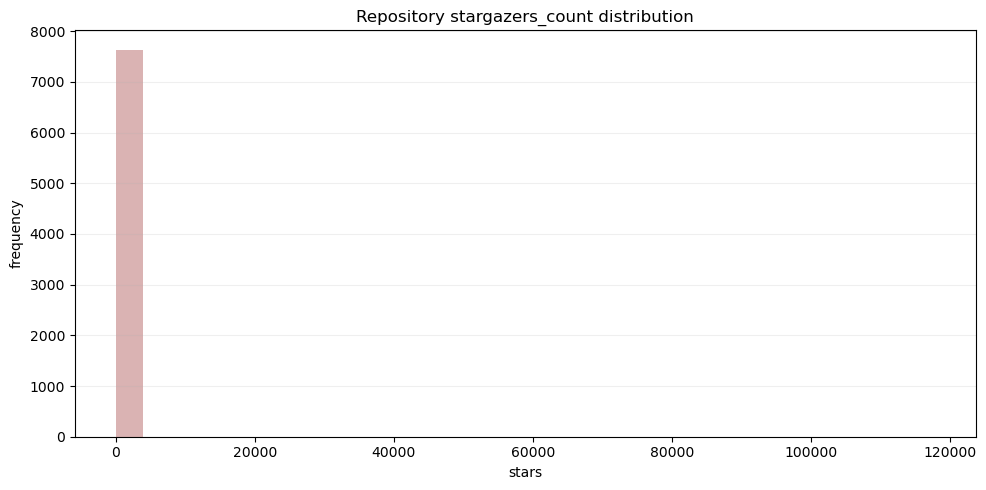

In [15]:
# Stars distribution, figura própria
if "stargazers_count" in df5.columns:
    stars = df5["stargazers_count"].fillna(0).astype(float)
    fig, ax = plt.subplots(figsize=(10, 5))
    pastel_hist(ax, stars, bins=30,
                title="Repository stargazers_count distribution",
                xlabel="stars")
    plt.tight_layout()
    plt.show()


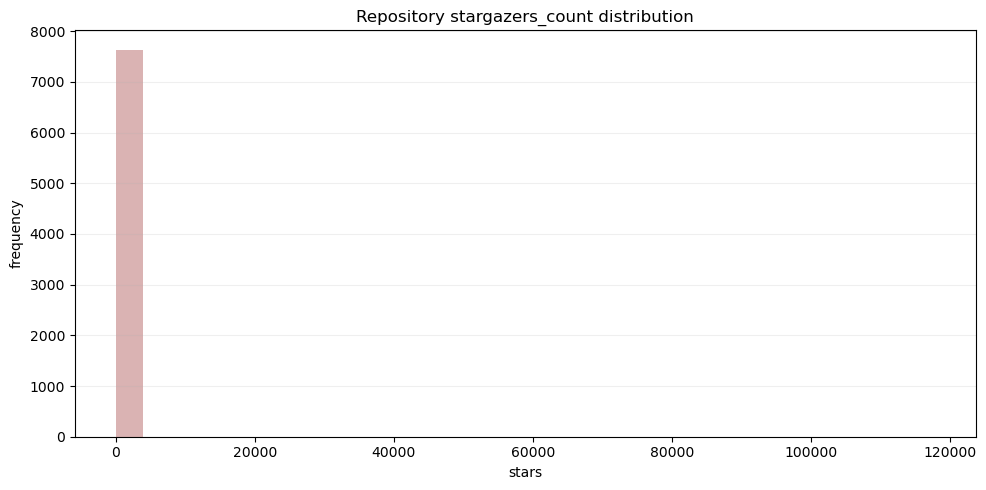

In [16]:
# Stars distribution, figura própria
if "stargazers_count" in df5.columns:
    stars = df5["stargazers_count"].fillna(0).astype(float)
    fig, ax = plt.subplots(figsize=(10, 5))
    pastel_hist(ax, stars, bins=30,
                title="Repository stargazers_count distribution",
                xlabel="stars")
    plt.tight_layout()
    plt.show()


In [17]:
# v2 metrics por tipo e nome, figura própria
df_v2 = df5[df5[Col.APIVERSION.value] == "v2"]
if not df_v2.empty:
    v2_metrics = (
        df_v2.groupby([Col.METRIC_TYPE.value, Col.METRIC_NAME.value])
        .size()
        .reset_index(name="counts")
    )
    pivot_table = (
        v2_metrics
        .pivot(index=Col.METRIC_TYPE.value, columns=Col.METRIC_NAME.value, values="counts")
        .fillna(0)
        .sort_index()
    )

    fig = plt.figure(figsize=(12, 6))
    ax = plt.gca()
    pivot_table.plot(kind="bar", stacked=True, ax=ax, color=_pastel(len(pivot_table.columns)))
    ax.set_title("v2 metrics by type and name")
    ax.set_xlabel("metric_type")
    ax.set_ylabel("count")
    ax.legend(title="metric_name", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_546913/1323834813.py:7: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  pastel_hist(ax, data_full.view("int64") // 10**9, bins=90,


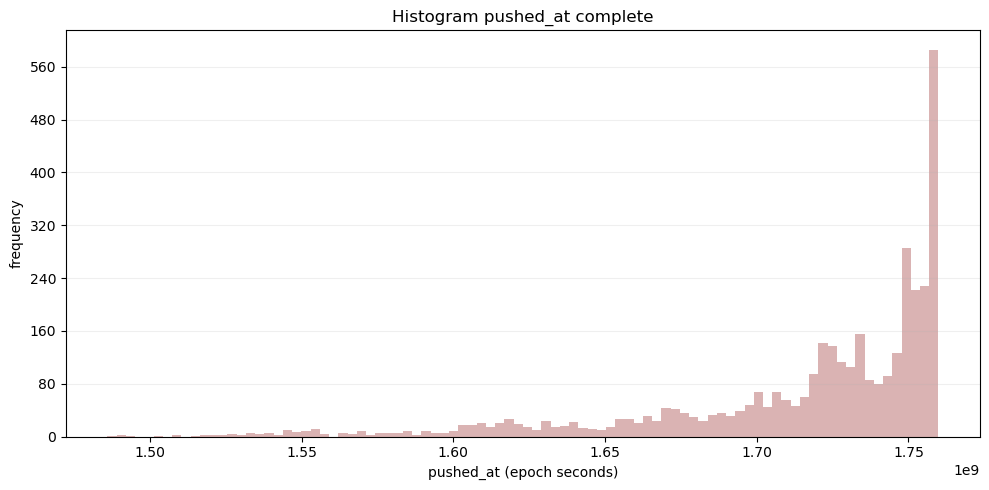

In [18]:
# Histogram pushed_at completo, figura separada
data_full = items_details["pushed_at"].dropna()
if not data_full.empty:
    # converte datetime para dias desde epoch para bins uniformes se necessário
    # aqui usamos bins por contagem simples
    fig, ax = plt.subplots(figsize=(10, 5))
    pastel_hist(ax, data_full.view("int64") // 10**9, bins=90,
                title="Histogram pushed_at complete",
                xlabel="pushed_at (epoch seconds)")
    # Opcional, rótulos de data não triviais. Mantemos epoch para desempenho em amostras grandes.
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_546913/65672727.py:5: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  pastel_hist(ax, data_filter.view("int64") // 10**9, bins=30,


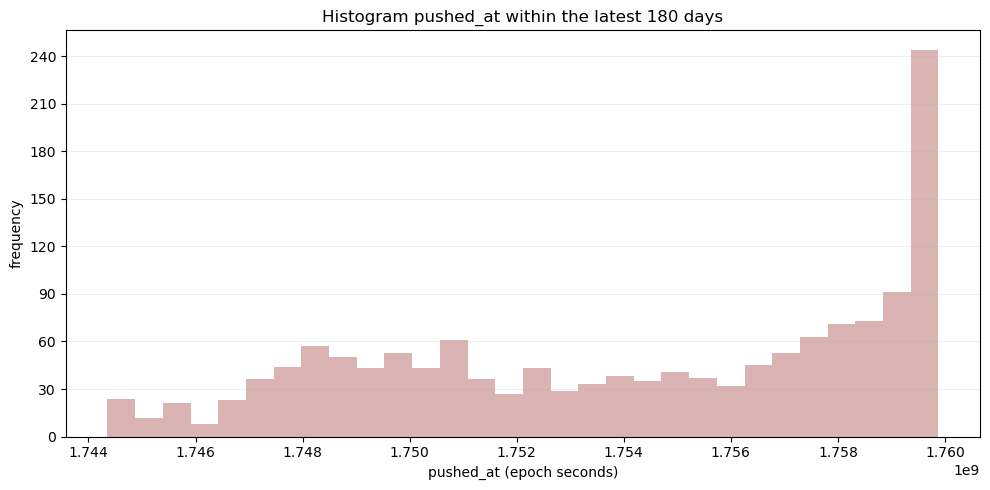

In [19]:
# Histogram pushed_at nos últimos 180 dias, figura separada
data_filter = filter_newer_pushed_at["pushed_at"].dropna()
if not data_filter.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    pastel_hist(ax, data_filter.view("int64") // 10**9, bins=30,
                title="Histogram pushed_at within the latest 180 days",
                xlabel="pushed_at (epoch seconds)")
    plt.tight_layout()
    plt.show()


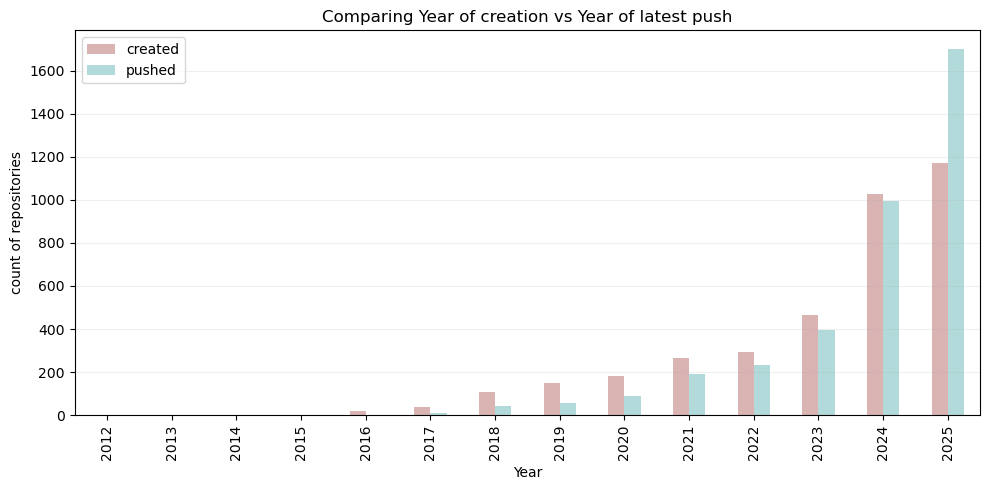

In [20]:
# Comparativo por ano, criação vs último push, figura separada
tmp = items_details.copy()
tmp["created_year"] = tmp["created_at"].dt.year
tmp["pushed_year"]  = tmp["pushed_at"].dt.year

created_year_count = tmp.groupby("created_year")["repo_name"].count()
pushed_year_count  = tmp.groupby("pushed_year")["repo_name"].count()

df_anos = pd.DataFrame({
    "created": created_year_count,
    "pushed": pushed_year_count
}).fillna(0).astype(int)

if not df_anos.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    df_anos.plot(kind="bar", ax=ax, color=_pastel(2))
    ax.set_title("Comparing Year of creation vs Year of latest push")
    ax.set_xlabel("Year")
    ax.set_ylabel("count of repositories")
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


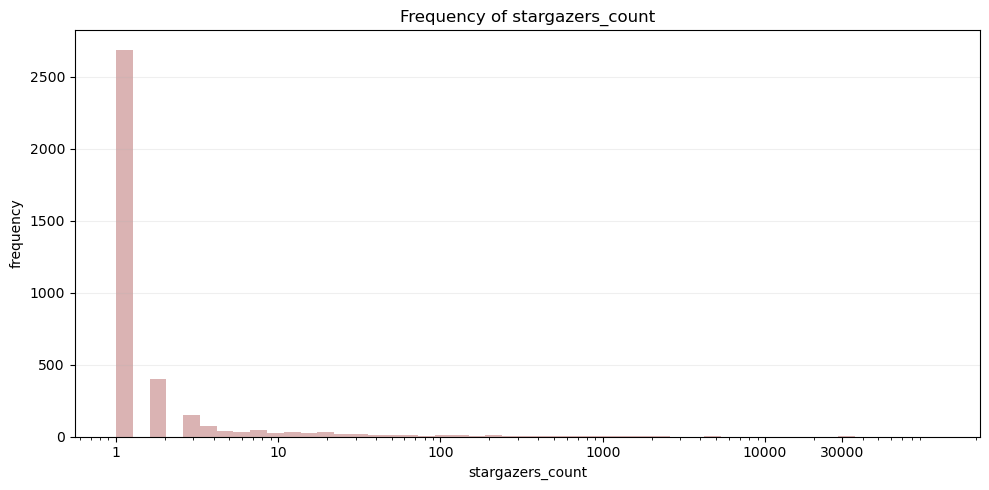

In [21]:
# Histograma em escala log, estrelas no conjunto completo, figura separada
data_full = items_details["stargazers_count"].fillna(0).astype(float)
if (data_full > 0).any():
    # desloca em +1 para incluir zeros no eixo log
    vals = data_full + 1.0
    bins_full = np.logspace(0, np.log10(vals.max() + 1), 50)
    ticks = [1, 10, 100, 1000, 10000, 30000]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(vals, bins=bins_full, color=_pastel(1)[0])
    ax.set_xscale("log")
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.set_title("Frequency of stargazers_count")
    ax.set_xlabel("stargazers_count")
    ax.set_ylabel("frequency")
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()


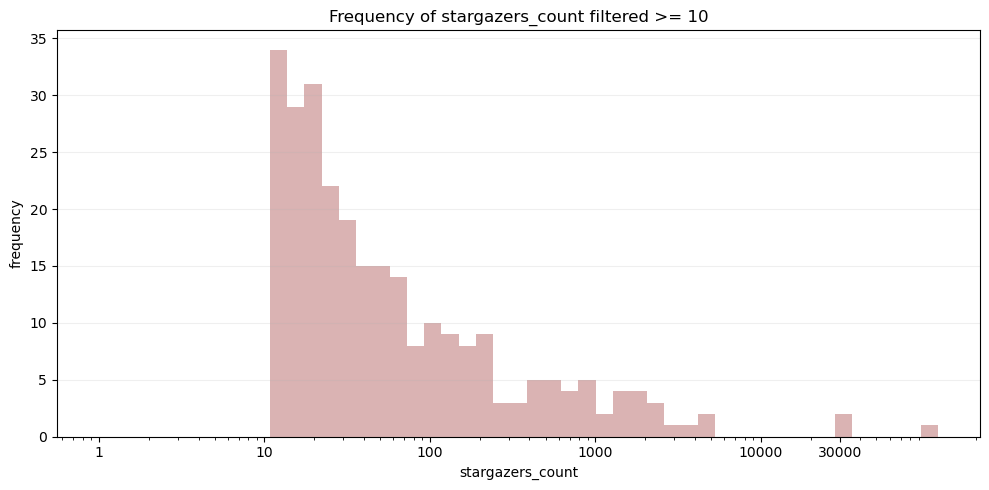

In [22]:
# Histograma em escala log, estrelas filtradas por limiar, figura separada
data_filter = filter_min_stars["stargazers_count"].fillna(0).astype(float)
if (data_filter > 0).any():
    vals_f = data_filter + 1.0
    bins_filter = np.logspace(0, np.log10(vals_f.max() + 1), 50)
    ticks = [1, 10, 100, 1000, 10000, 30000]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(vals_f, bins=bins_filter, color=_pastel(1)[0])
    ax.set_xscale("log")
    ax.set_xticks(ticks)
    ax.set_xticklabels([str(t) for t in ticks])
    ax.set_title(f"Frequency of stargazers_count filtered >= {min_stars}")
    ax.set_xlabel("stargazers_count")
    ax.set_ylabel("frequency")
    ax.grid(axis="y", alpha=0.2)
    plt.tight_layout()
    plt.show()
